In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
log = pd.read_csv('transformed_dataset.csv')
print('Log shape:', log.shape)
print(log.head(10))

grades = pd.read_csv('grades_data.csv')
print('\nGrades shape:', grades.shape)
print(grades.head(10))

Log shape: (9829, 5)
   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:5

In [2]:
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(grouped.columns), axis=1)
grouped.columns = [f"{col}totalCount" for col in grouped.columns]
assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape}  →  {assignment_counts.shape[0]} students, "
  f"{assignment_counts.shape[1]-1} count features + userID")
assignment_counts.head()

Shape: (54, 6)  →  54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


In [3]:
time_totals = (
log.groupby(['userID', 'assignment'])['view_length'].sum().unstack(fill_value=0))
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')
print(f"Final shape: {assignments.shape}")
print("Columns:", assignments.columns.tolist())
assignments.head()

Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


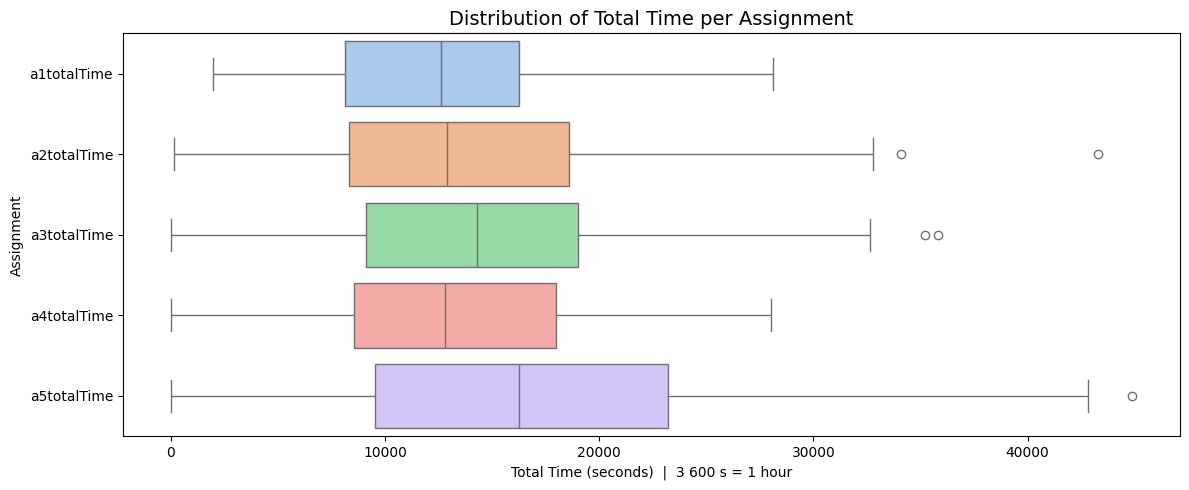

In [4]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignments.filter(like='totalTime'), orient='h', palette='pastel')
plt.title('Distribution of Total Time per Assignment', fontsize=14)
plt.xlabel('Total Time (seconds)  |  3 600 s = 1 hour')
plt.ylabel('Assignment')
plt.tight_layout()
plt.show()

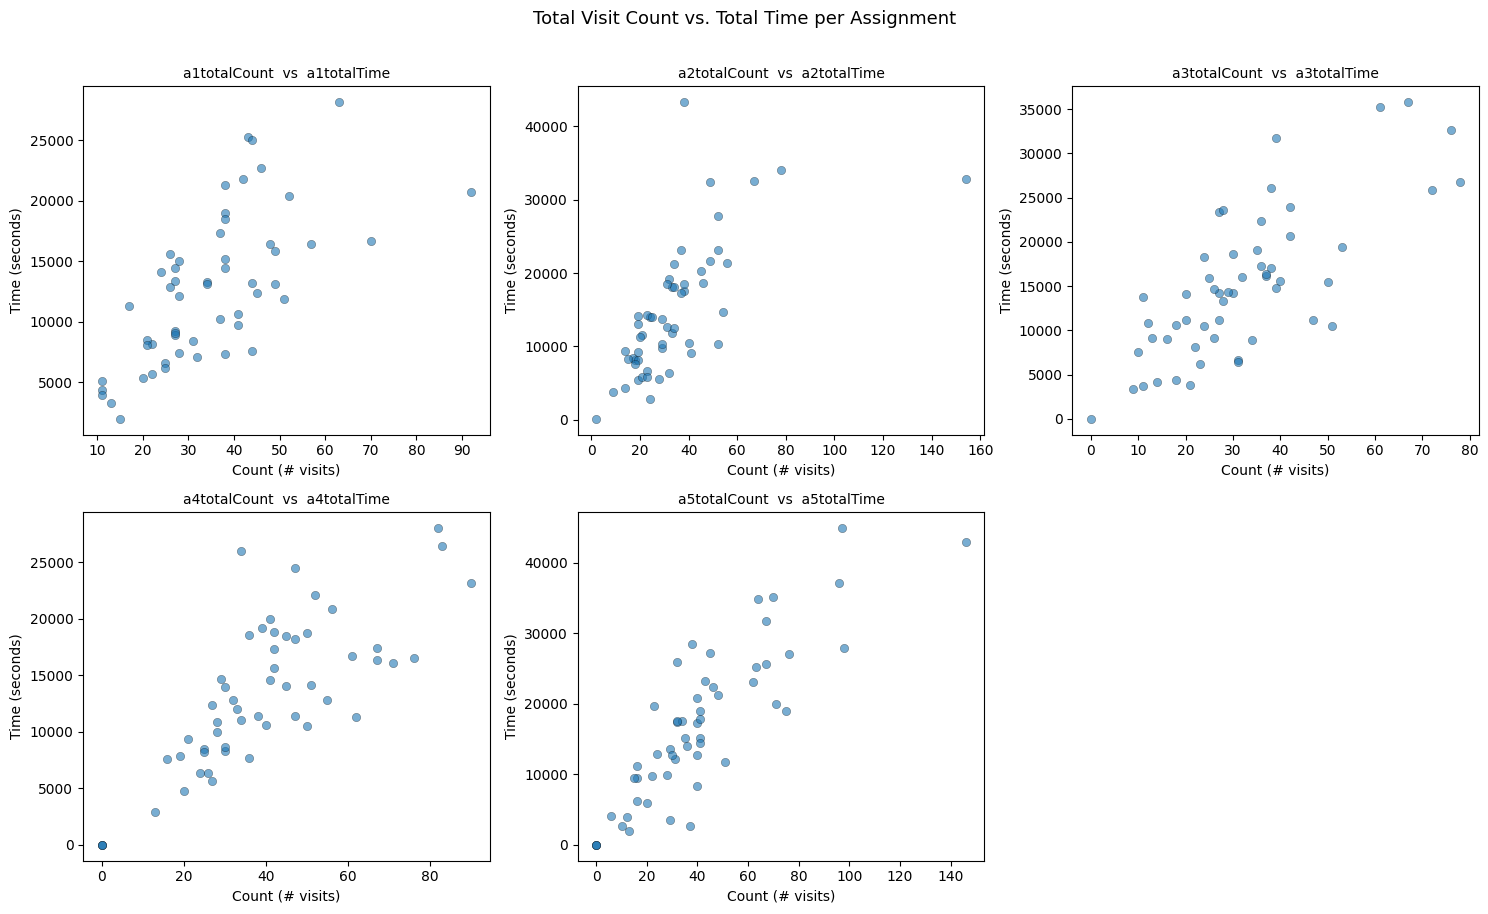

Max total time across all students/assignments: 44873 s = 12.5 hours


In [5]:
count_cols = assignments.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(count_cols):
  time_col = col.replace('totalCount', 'totalTime')
  axes[i].scatter(assignments[col], assignments[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
  axes[i].set_title(f"{col}  vs  {time_col}", fontsize=10)
  axes[i].set_xlabel('Count (# visits)')
  axes[i].set_ylabel('Time (seconds)')

for j in range(n, len(axes)):
  axes[j].set_visible(False)

plt.suptitle('Total Visit Count vs. Total Time per Assignment', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
max_time = assignments.filter(like='totalTime').max().max()
print(f"Max total time across all students/assignments: {max_time:.0f} s = {max_time/3600:.1f} hours")

In [6]:
grades = pd.merge(grades, assignments, on='userID', how='left')
print(f"Grades DataFrame shape: {grades.shape}")
grades.head()

Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [7]:
correlation_results = {}
for i in range(1, 6):
  grade_col = f'A{i}'
  time_col  = f'a{i}totalTime'
  
  if grade_col in grades.columns and time_col in grades.columns:
    corr = grades[[grade_col, time_col]].corr().iloc[0, 1]
    correlation_results[grade_col] = round(corr, 3)

print("Correlation between assignment grade and total time on that assignment:")
for k, v in correlation_results.items():
  print(f"  {k} ↔ {k.lower()}totalTime :  r = {v}")

Correlation between assignment grade and total time on that assignment:
  A1 ↔ a1totalTime :  r = 0.351
  A2 ↔ a2totalTime :  r = 0.207
  A3 ↔ a3totalTime :  r = 0.444
  A4 ↔ a4totalTime :  r = 0.551
  A5 ↔ a5totalTime :  r = 0.555


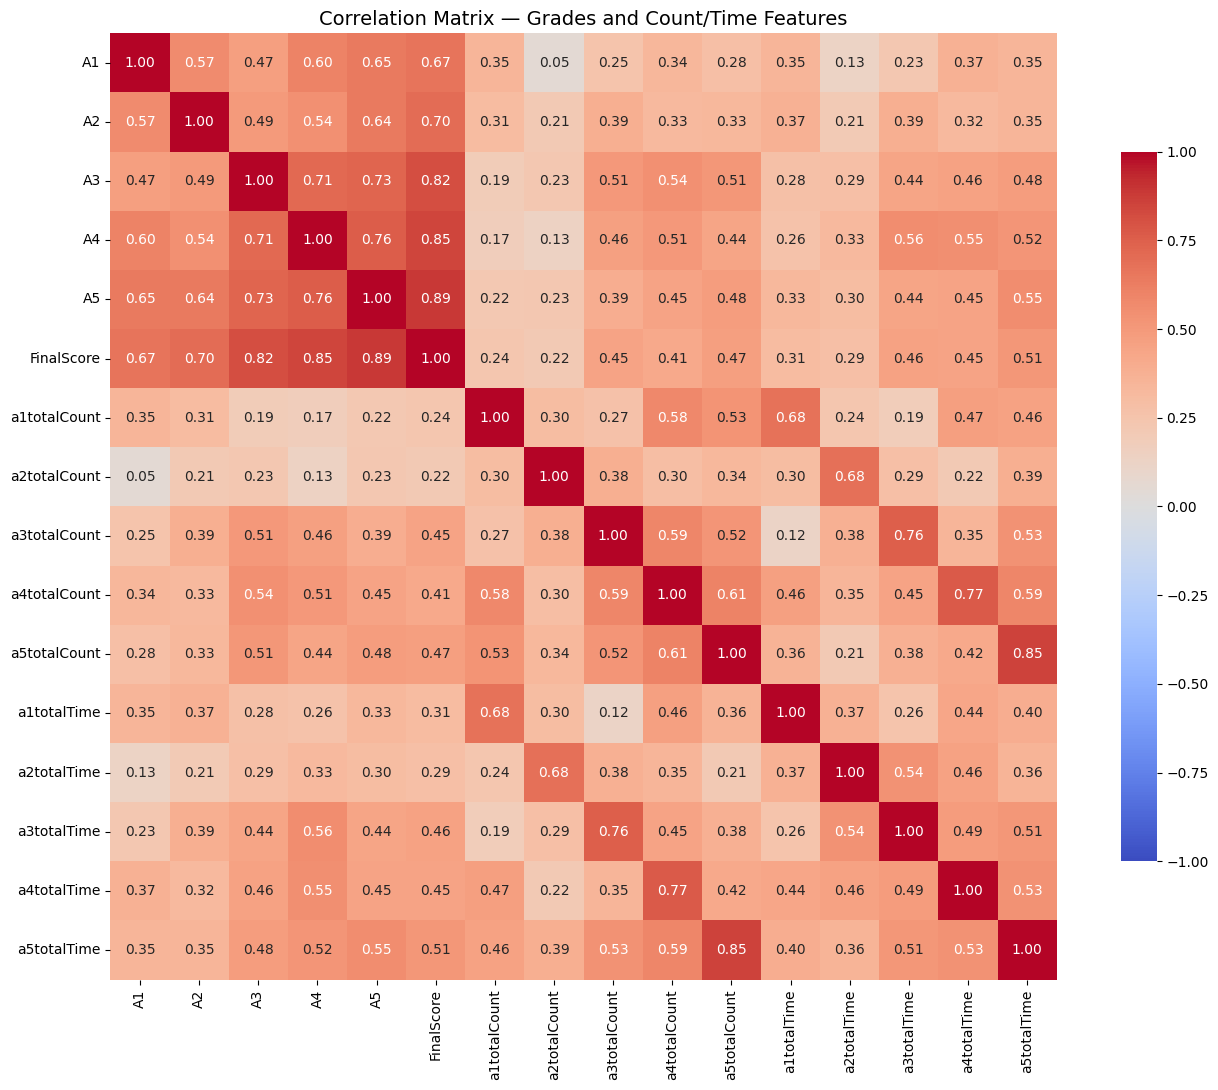


📌 Observation: The correlation between totalCount and totalTime for the same assignment is in the 0.68–0.85 range.
   This means they are related, but NOT redundant — each carries unique information.


In [8]:
correlation_matrix = grades.drop(columns=['userID']).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
  correlation_matrix,
  annot=True, fmt=".2f", cmap='coolwarm',
  square=True, cbar_kws={"shrink": .75},
  vmin=-1, vmax=1
)
plt.title('Correlation Matrix — Grades and Count/Time Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📌 Observation: The correlation between totalCount and totalTime for the same"
      " assignment is in the 0.68–0.85 range.")
print("   This means they are related, but NOT redundant — each carries unique information.")

In [9]:

a1deadline = pd.to_datetime('2020-05-27 23:59:00-07:00')
a2deadline = pd.to_datetime('2020-06-15 23:59:00-07:00')
a3deadline = pd.to_datetime('2020-07-05 23:59:00-07:00')
a4deadline = pd.to_datetime('2020-07-15 23:59:00-07:00')
a5deadline = pd.to_datetime('2020-08-09 23:59:00-07:00')
deadlines = {
  'a1': a1deadline,
  'a2': a2deadline,
  'a3': a3deadline,
  'a4': a4deadline,
  'a5': a5deadline,
}
print("Deadlines loaded:")
for k, v in deadlines.items():
  print(f"  {k}: {v.date()}")

Deadlines loaded:
  a1: 2020-05-27
  a2: 2020-06-15
  a3: 2020-07-05
  a4: 2020-07-15
  a5: 2020-08-09


In [10]:
log['start_time'] = pd.to_datetime(log['start_time'], utc=True)
log['date'] = log['start_time'].dt.date
rows = []
for (user, assignment), group in log.groupby(['userID', 'assignment']):
  if assignment not in deadlines:
    continue
  deadline = deadlines[assignment]
  dates = sorted(set(group['date']))
  days_before = [(deadline.date() - d).days for d in dates]
  days_in_last_week = [d for d in dates if 0 <= (deadline.date() - d).days <= 7]
  rows.append({
    'userID':              user,
    'assignment':          assignment,

    'firstDay':            days_before[0] if len(days_before) >= 1 else None,

    'secondDay':           days_before[1] if len(days_before) >= 2 else None,

    'firstSecondGap':      (days_before[0] - days_before[1]) if len(days_before) >= 2 else None,

    'nDays':               len(dates),
    'nDaysFinalWeek':      len(days_in_last_week),

    'nDaysBeforeFinalWeek': len([d for d in days_before if d > 7]),
    'nDaysAfterDeadline':  len([d for d in days_before if d < 0]),
  })

activity_summary = pd.DataFrame(rows)
print(f"activity_summary shape: {activity_summary.shape}")
activity_summary.head(10)

activity_summary shape: (263, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,-2184,-2187.0,3.0,7,0,0,7
1,100001,a2,-2173,-2179.0,6.0,11,0,0,11
2,100001,a3,-2181,-2185.0,4.0,9,0,0,9
3,100001,a4,-2187,-2188.0,1.0,9,0,0,9
4,100001,a5,-2176,-2177.0,1.0,8,0,0,8
5,100002,a1,-2175,-2182.0,7.0,9,0,0,9
6,100002,a2,-2172,-2173.0,1.0,14,0,0,14
7,100002,a3,-2173,-2176.0,3.0,13,0,0,13
8,100002,a4,-2185,-2189.0,4.0,6,0,0,6
9,100002,a5,-2164,-2167.0,3.0,14,0,0,14
